# Large Backbone Ablation

Fair model comparison using the shared large-backbone setting: ViT-L/16 for encoder models and LTX-13B for LTX-Video.


[seed coverage] OK: large_ablation.ipynb selected plotted rows: 42 rows have seeds 42,101,102.


# Large Backbone Ablation

This notebook compares models under a shared large-backbone setting. All encoder models use `ViT-L/16`; LTX uses `LTX-2B` and `LTX-13B`. For each dataset, probe, and model, the plotted value is the best test primary metric across the available large-backbone rows.

**Best-test rows used in the plot**

,Dataset,Model,Backbone,Experiment,Probe,Selected layer,Best test primary used for selection,Plotted test primary,Plotted test primary std,Test accuracy,Test accuracy std
17,IntPhys2,LTX-13B,LTX-13B,ltx,Attentive,34,48.37,48.37,6.89,66.83,1.98
18,IntPhys2,LTX-2B,LTX-2B,ltx,Attentive,36,29.41,29.41,5.19,58.99,1.50
14,IntPhys2,V-JEPA,ViT-L/16,same_L,Attentive,18,72.55,72.55,3.40,82.52,4.23
15,IntPhys2,V-JEPA 2,ViT-L/16,same_L,Attentive,18,64.71,64.71,5.88,76.96,5.52
16,IntPhys2,V-JEPA 2.1,ViT-L/16,same_L,Attentive,24,67.32,67.32,8.84,77.29,5.20
19,IntPhys2,VideoMAE,ViT-L/16,same_L,Attentive,24,69.93,69.93,4.08,78.27,2.83
20,IntPhys2,VideoMAE-v2,ViT-L/16,same_L,Attentive,18,56.86,56.86,1.96,70.59,2.25
3,IntPhys2,LTX-13B,LTX-13B,ltx,Linear,noise_0.1_block_24,49.67,49.67,3.00,60.62,1.02
4,IntPhys2,LTX-2B,LTX-2B,ltx,Linear,noise_0.7_block_14,23.53,23.53,6.79,53.92,1.47
0,IntPhys2,V-JEPA,ViT-L/16,same_L,Linear,24,48.37,48.37,5.99,56.37,3.43


**Loaded-row coverage, not directly plotted**

,Dataset,Model,Backbone,Experiment,Probe,n_loaded_rows,best_validation_any_row,best_test_any_row
2,IntPhys2,LTX-13B,LTX-13B,ltx,Attentive,4,56.86,43.14
0,IntPhys2,LTX-13B,LTX-13B,ltx,Linear,40,45.10,49.02
1,IntPhys2,LTX-13B,LTX-13B,ltx,MLP,40,43.14,47.06
5,IntPhys2,LTX-2B,LTX-2B,ltx,Attentive,4,21.57,35.29
3,IntPhys2,LTX-2B,LTX-2B,ltx,Linear,40,29.41,27.45
4,IntPhys2,LTX-2B,LTX-2B,ltx,MLP,40,29.41,27.45
8,IntPhys2,V-JEPA,ViT-L/16,same_L,Attentive,4,78.43,74.51
6,IntPhys2,V-JEPA,ViT-L/16,same_L,Linear,4,43.14,47.06
7,IntPhys2,V-JEPA,ViT-L/16,same_L,MLP,4,50.98,49.02
11,IntPhys2,V-JEPA 2,ViT-L/16,same_L,Attentive,4,68.63,70.59


**Pairwise significance annotations** | backend: SciPy/manual brackets | test: Welch from summary statistics | correction: Holm within each dataset/probe family | alpha=0.05

**Holm-significant model pairs used as plot annotations**

,Dataset,Probe,Model A,Model B,mean_a,mean_b,delta_b_minus_a,p_uncorrected,p_holm,stars
46,IntPhys2,Attentive,V-JEPA,LTX-2B,72.55,29.41,-43.14,0.000611,0.0123,*
58,IntPhys2,Attentive,VideoMAE,LTX-2B,69.93,29.41,-40.52,0.000586,0.0123,*
51,IntPhys2,Attentive,V-JEPA 2,LTX-2B,64.71,29.41,-35.30,0.00155,0.0295,*
30,IntPhys2,MLP,V-JEPA 2,LTX-2B,52.29,26.80,-25.49,0.0018,0.0379,*
34,IntPhys2,MLP,V-JEPA 2.1,LTX-2B,51.63,26.80,-24.84,0.00193,0.0379,*
37,IntPhys2,MLP,VideoMAE,LTX-2B,42.48,26.80,-15.69,0.00189,0.0379,*
25,IntPhys2,MLP,V-JEPA,LTX-2B,50.33,26.80,-23.53,0.00221,0.0397,*
39,IntPhys2,MLP,VideoMAE-v2,LTX-2B,50.33,26.80,-23.53,0.00221,0.0397,*
123,MVP,Attentive,VideoMAE-v2,LTX-2B,87.87,55.61,-32.26,0.00014,0.00252,**
107,MVP,Attentive,V-JEPA,VideoMAE,93.46,89.79,-3.67,0.000533,0.00905,**


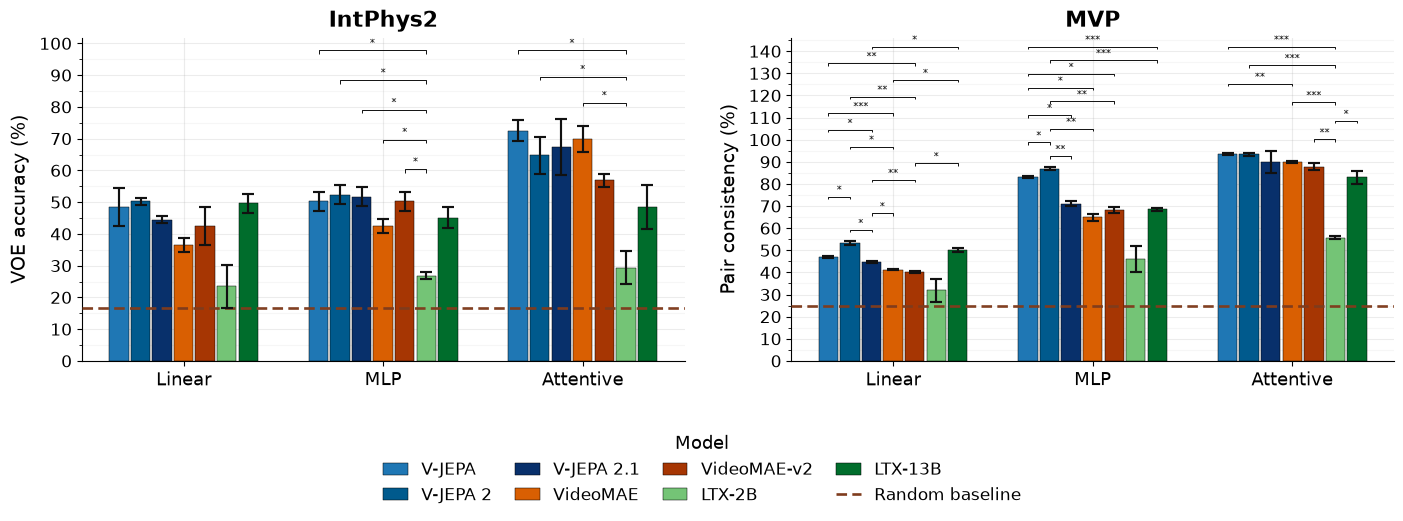

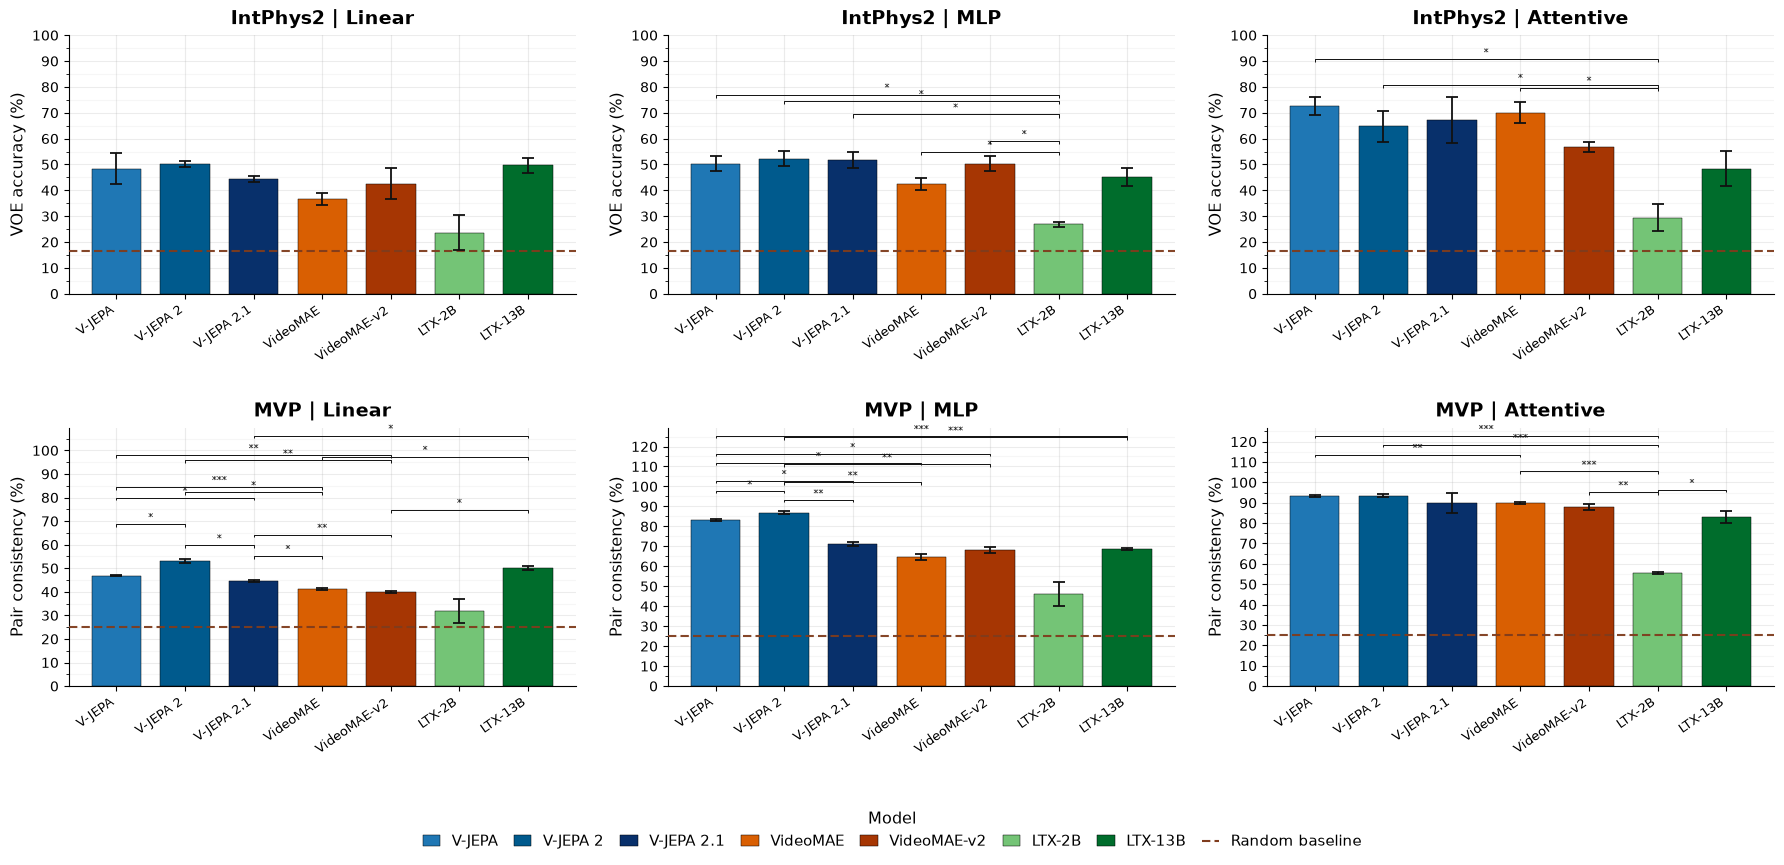

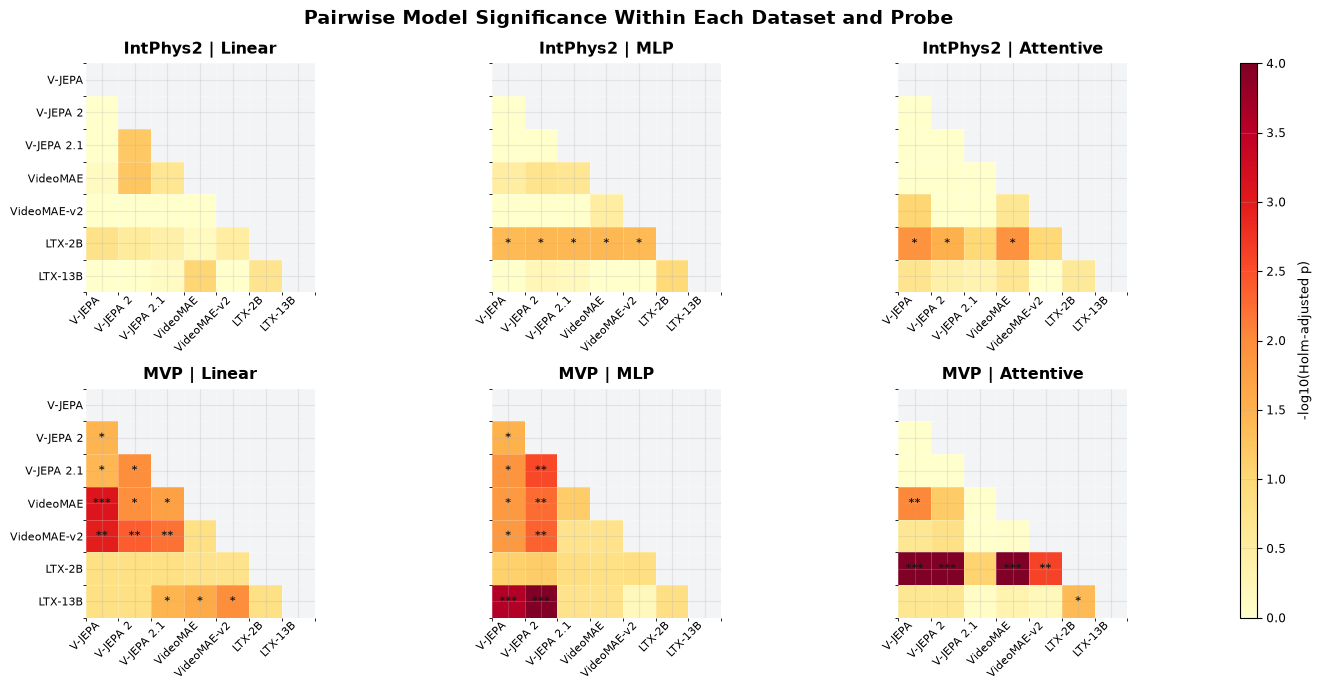

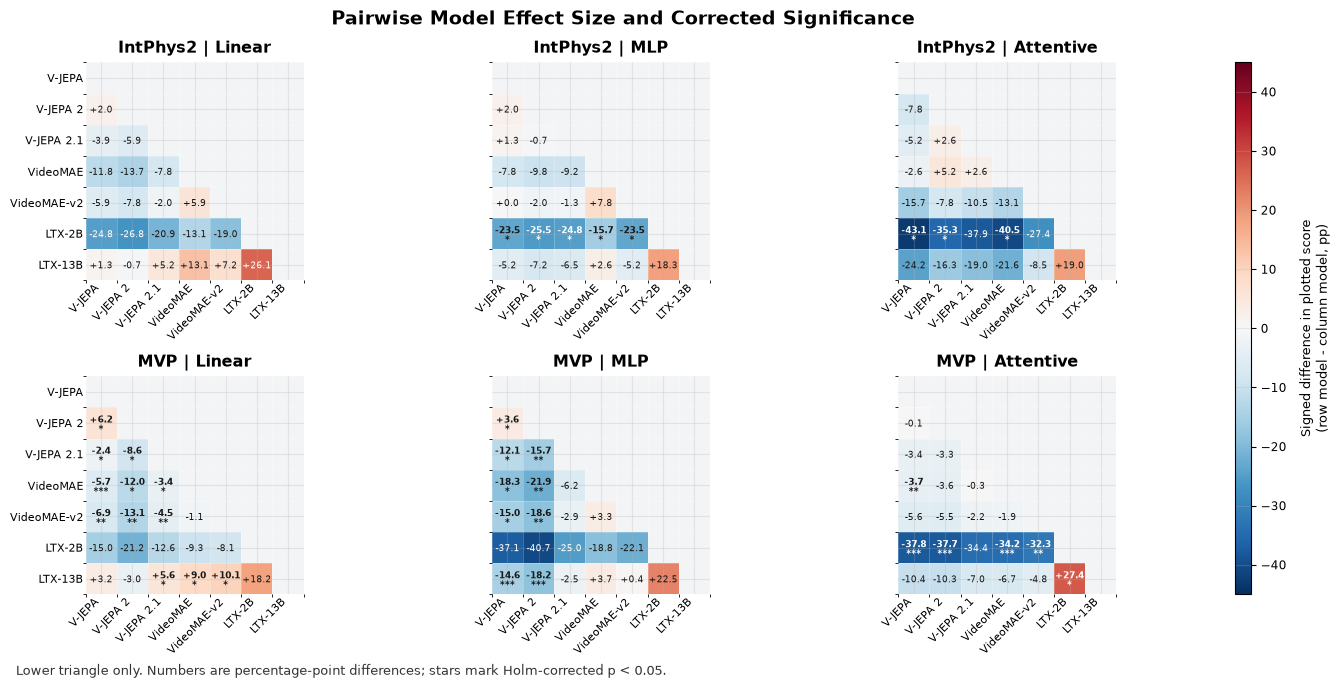

In [2]:
from pathlib import Path
import os
import re
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/probe4physics_matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp/probe4physics_cache')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)

import importlib
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from scipy import stats
except Exception:
    stats = None

try:
    from statannotations.Annotator import Annotator as StatAnnotator
except Exception:
    StatAnnotator = None

try:
    from IPython.display import Markdown, display
except ModuleNotFoundError:
    class Markdown(str):
        pass
    def display(obj):
        print(obj)

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 180)
if sns is not None:
    sns.set_theme(style='whitegrid', context='notebook')
else:
    plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.25})
plt.rcParams['figure.max_open_warning'] = 0
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

def find_repo_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for candidate in [current, *current.parents]:
        if (candidate / 'results').exists() and (candidate / 'run.py').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root containing results/ and run.py')

REPO_ROOT = find_repo_root()
NOTEBOOK_DIR = REPO_ROOT / 'notebooks'
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
import plot_colors
importlib.reload(plot_colors)
from plot_colors import MODEL_COLORS, PROBE_COLORS, REFERENCE_COLORS
from seed_variance_loader import load_ready_seed_summary, report_seed_coverage

RESULTS_DIR = REPO_ROOT / 'results'
MVP_XLSX = RESULTS_DIR / 'mvp_primary_db.xlsx'
INTPHYS_XLSX = RESULTS_DIR / 'intphys_primary_db.xlsx'

DATASET_ORDER = ['intphys2', 'mvp']
DATASET_LABEL = {'mvp': 'MVP', 'intphys2': 'IntPhys2'}
PRIMARY_LABEL = {'mvp': 'Pair consistency (%)', 'intphys2': 'VOE accuracy (%)'}
RANDOM_BASELINE = {'mvp': 25.0, 'intphys2': 100.0 / 6.0}
PROBE_ORDER = ['linear', 'mlp', 'temporal_attn']
PROBE_LABEL = {'linear': 'Linear', 'mlp': 'MLP', 'temporal_attn': 'Attentive'}
MODEL_ORDER = ['jepa_v1', 'jepa_v2', 'jepa_v2_1', 'videomae', 'videomae_v2', 'ltx_video_2b', 'ltx_video_13b']
MODEL_LABEL = {
    'jepa_v1': 'V-JEPA',
    'jepa_v2': 'V-JEPA 2',
    'jepa_v2_1': 'V-JEPA 2.1',
    'videomae': 'VideoMAE',
    'videomae_v2': 'VideoMAE-v2',
    'ltx_video_2b': 'LTX-2B',
    'ltx_video_13b': 'LTX-13B',
}
SHEET_TO_MODEL_KEY = {
    'V-JEPA': 'jepa_v1',
    'V-JEPA 2': 'jepa_v2',
    'V-JEPA 2.1': 'jepa_v2_1',
    'VideoMAE': 'videomae',
    'VideoMAE-v2': 'videomae_v2',
    'LTX-Video': 'ltx_video',
}
TARGET_BACKBONE = {
    'jepa_v1': 'ViT-L/16',
    'jepa_v2': 'ViT-L/16',
    'jepa_v2_1': 'ViT-L/16',
    'videomae': 'ViT-L/16',
    'videomae_v2': 'ViT-L/16',
    'ltx_video_2b': 'LTX-2B',
    'ltx_video_13b': 'LTX-13B',
}
TARGET_EXPERIMENT = {
    'jepa_v1': 'same_L',
    'jepa_v2': 'same_L',
    'jepa_v2_1': 'same_L',
    'videomae': 'same_L',
    'videomae_v2': 'same_L',
    'ltx_video_2b': 'ltx',
    'ltx_video_13b': 'ltx',
}

SIGNIFICANCE_ANNOTATIONS_ENABLED = True
SIGNIFICANCE_ALPHA = 0.05
SIGNIFICANCE_CORRECTION = 'holm'
SIGNIFICANCE_TEST = 'welch_summary'
SIGNIFICANCE_HIDE_NS = True
SIGNIFICANCE_BRACKET_BASE_PAD_PP = 4.0
SIGNIFICANCE_BRACKET_TOP_PAD_PP = 4.0
SIGNIFICANCE_BRACKET_MIN_STEP_PP = 5.5
SIGNIFICANCE_BRACKET_HEIGHT_PP = 1.1

SAVE_RENDERED_FIGURES = True
FIGURE_DPI = 220
EFFECT_HEATMAP_ABS_LIMIT = None

for required in [MVP_XLSX, INTPHYS_XLSX]:
    if not required.exists():
        raise FileNotFoundError(f'Missing required workbook: {required}')


SEED_MERGE_KEYS = ['dataset', 'experiment', 'model_label', 'backbone', 'probe', 'layer_key']
SEED_STAT_COLUMNS = [
    'n_seeds', 'seeds', 'seed_source',
    'test_primary_mean', 'test_primary_std', 'test_accuracy_mean', 'test_accuracy_std',
    'val_primary_mean', 'val_primary_std', 'val_accuracy_mean', 'val_accuracy_std',
]

def dataset_key(value):
    text = str(value).strip().lower()
    if text == 'intphys2':
        return 'intphys2'
    if text == 'mvp':
        return 'mvp'
    return text

def normalized_layer_label(value):
    if value is None or pd.isna(value):
        return ''
    text = re.sub(r'\s+', ' ', str(value).strip().lower())
    return text

def numeric_layer_key(value):
    number = pd.to_numeric(pd.Series([value]), errors='coerce').iloc[0]
    if pd.isna(number):
        return ''
    return f'id:{number:g}'

def label_layer_key(value):
    label = normalized_layer_label(value)
    return f'label:{label}' if label else ''

def row_layer_key(row):
    return numeric_layer_key(row.get('layer')) or label_layer_key(row.get('layer_label'))

def load_seed_summary():
    return load_ready_seed_summary(
        RESULTS_DIR,
        seed_merge_keys=SEED_MERGE_KEYS,
        seed_stat_columns=SEED_STAT_COLUMNS,
    )

def attach_seed_stats(df):
    seeds = load_seed_summary()
    base = df.drop(columns=[c for c in [*SEED_STAT_COLUMNS, 'layer_key'] if c in df.columns], errors='ignore').copy()
    base['layer'] = pd.to_numeric(base['layer'], errors='coerce')
    if {'model_label', 'backbone'}.issubset(base.columns):
        ltx_mask = base['backbone'].isin(['LTX-2B', 'LTX-13B'])
        base.loc[ltx_mask, 'model_label'] = base.loc[ltx_mask, 'backbone']
    base['layer_key'] = base.apply(row_layer_key, axis=1)
    merged = base.merge(seeds, on=SEED_MERGE_KEYS, how='left', validate='many_to_one')
    merged['plot_test_primary'] = merged['test_primary_mean'].combine_first(merged['test_primary'])
    merged['plot_test_primary_std'] = pd.to_numeric(merged['test_primary_std'], errors='coerce')
    merged['plot_test_accuracy'] = merged['test_accuracy_mean'].combine_first(merged['test_accuracy'])
    merged['plot_test_accuracy_std'] = pd.to_numeric(merged['test_accuracy_std'], errors='coerce')
    merged['plot_val_primary'] = merged['val_primary_mean'].combine_first(merged['val_primary'])
    merged['plot_val_primary_std'] = pd.to_numeric(merged['val_primary_std'], errors='coerce')
    return merged

def yerr_or_none(values):
    err = pd.to_numeric(values, errors='coerce')
    return None if err.isna().all() else err.to_numpy(dtype=float)


def canonical_probe(value):
    text = str(value).strip().lower()
    if text == 'linear':
        return 'linear'
    if text == 'mlp':
        return 'mlp'
    if text in {'attentive', 'temporalattn', 'temporal_attn', 'temporal attentive'}:
        return 'temporal_attn'
    return text or None

def parse_ltx_slot(label):
    if label is None or pd.isna(label):
        return (np.nan, np.nan)
    match = re.search(r'noise_([0-9.]+)_block_(\d+)', str(label))
    if not match:
        return (np.nan, np.nan)
    return (float(match.group(1)), int(match.group(2)))

def parse_primary_workbook(path, dataset):
    frames = []
    xl = pd.ExcelFile(path)
    for sheet in xl.sheet_names:
        raw = xl.parse(sheet)
        cols = list(raw.columns)
        starts = [idx for idx, col in enumerate(cols) if not str(col).startswith('Unnamed') and 'primary metric' in str(col).lower()]
        for start in starts:
            end = min(start + 11, len(cols))
            title = str(cols[start])
            backbone = title.split(' - primary metric:', 1)[0].strip()
            block = raw.iloc[:, start:end].copy()
            headers = [str(item).strip() for item in block.iloc[0].tolist()]
            block = block.iloc[1:].copy()
            block.columns = headers
            block = block.dropna(how='all')
            if 'Experiment' not in block.columns:
                continue
            block = block[block['Experiment'].notna()].copy()
            if block.empty:
                continue
            block['dataset'] = dataset
            block['workbook'] = path.name
            block['sheet'] = sheet
            block['model_key'] = SHEET_TO_MODEL_KEY.get(sheet, sheet)
            block['backbone'] = backbone
            frames.append(block)
    if not frames:
        raise ValueError(f'No parseable result blocks found in {path}')
    return pd.concat(frames, ignore_index=True, sort=False)

def load_results():
    raw = pd.concat([
        parse_primary_workbook(INTPHYS_XLSX, 'intphys2'),
        parse_primary_workbook(MVP_XLSX, 'mvp'),
    ], ignore_index=True, sort=False)
    rename = {
        'Experiment': 'experiment',
        'Probe': 'probe_raw',
        'Layer': 'layer',
        'Layer Label': 'layer_label',
        'Selected LR': 'selected_lr',
        'Train Accuracy': 'train_accuracy',
        'Val Accuracy': 'val_accuracy',
        'Test Accuracy': 'test_accuracy',
        'Train Primary Metric': 'train_primary',
        'Val Primary Metric': 'val_primary',
        'Test Primary Metric': 'test_primary',
    }
    df = raw.rename(columns=rename).copy()
    df['probe'] = df['probe_raw'].map(canonical_probe)
    for col in ['layer', 'selected_lr', 'train_accuracy', 'val_accuracy', 'test_accuracy', 'train_primary', 'val_primary', 'test_primary']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['layer_label'] = df['layer_label'].astype('string')
    df['plot_model_key'] = df['model_key']
    df.loc[df['model_key'].eq('ltx_video') & df['backbone'].eq('LTX-2B'), 'plot_model_key'] = 'ltx_video_2b'
    df.loc[df['model_key'].eq('ltx_video') & df['backbone'].eq('LTX-13B'), 'plot_model_key'] = 'ltx_video_13b'
    df['model_label'] = df['plot_model_key'].map(MODEL_LABEL).fillna(df['sheet'])
    df['target_backbone'] = df['plot_model_key'].map(TARGET_BACKBONE)
    df['target_experiment'] = df['plot_model_key'].map(TARGET_EXPERIMENT)
    df['is_large_ablation_row'] = df['plot_model_key'].isin(MODEL_ORDER) & df['backbone'].eq(df['target_backbone']) & df['experiment'].eq(df['target_experiment'])
    slots = df['layer_label'].map(parse_ltx_slot)
    df['ltx_noise_level'] = [slot[0] for slot in slots]
    df['ltx_block'] = [slot[1] for slot in slots]
    df = attach_seed_stats(df)
    return df

def select_best_by_test(df):
    candidates = df.dropna(subset=['plot_test_primary']).copy()
    ordered = candidates.sort_values(['dataset', 'probe', 'plot_model_key', 'plot_test_primary', 'plot_test_accuracy', 'test_primary', 'val_primary'])
    best = ordered.groupby(['dataset', 'probe', 'plot_model_key'], group_keys=False).tail(1).copy()
    best['primary_score'] = best['plot_test_primary']
    best['primary_score_std'] = best['plot_test_primary_std']
    best['selection_score'] = best['plot_test_primary']
    return best.reset_index(drop=True)

def show_table(df, title):
    display(Markdown(f'**{title}**'))
    display(df.style.format(precision=2, na_rep=''))

all_results = load_results()
large_rows = all_results[all_results['is_large_ablation_row']].copy()
best_large = select_best_by_test(large_rows)
large_seed_coverage_issues = report_seed_coverage(
    best_large,
    'large_ablation.ipynb selected plotted rows',
    key_columns=['dataset', 'experiment', 'model_label', 'backbone', 'probe', 'layer', 'layer_label', 'layer_key'],
)

display(Markdown('# Large Backbone Ablation'))
display(Markdown(
    'This notebook compares models under a shared large-backbone setting. '
    'All encoder models use `ViT-L/16`; LTX uses `LTX-2B` and `LTX-13B`. '
    'For each dataset, probe, and model, the plotted value is the best test primary metric across the available large-backbone rows.'
))

summary = best_large.copy()
summary['Dataset'] = summary['dataset'].map(DATASET_LABEL)
summary['Probe'] = summary['probe'].map(PROBE_LABEL)
summary = summary.rename(columns={
    'model_label': 'Model',
    'backbone': 'Backbone',
    'experiment': 'Experiment',
    'layer_label': 'Selected layer',
    'selection_score': 'Best test primary used for selection',
    'primary_score': 'Plotted test primary',
    'primary_score_std': 'Plotted test primary std',
    'plot_test_accuracy': 'Test accuracy',
    'plot_test_accuracy_std': 'Test accuracy std',
})
show_table(
    summary[[
        'Dataset', 'Model', 'Backbone', 'Experiment', 'Probe', 'Selected layer',
        'Best test primary used for selection', 'Plotted test primary', 'Plotted test primary std',
        'Test accuracy', 'Test accuracy std',
    ]]
    .sort_values(['Dataset', 'Probe', 'Model']),
    'Best-test rows used in the plot'
)

coverage = (
    large_rows.groupby(['dataset', 'model_label', 'backbone', 'experiment', 'probe'], as_index=False)
    .agg(n_loaded_rows=('test_primary', 'size'), best_validation_any_row=('val_primary', 'max'), best_test_any_row=('test_primary', 'max'))
)
coverage['Dataset'] = coverage['dataset'].map(DATASET_LABEL)
coverage['Probe'] = coverage['probe'].map(PROBE_LABEL)
coverage = coverage.rename(columns={
    'model_label': 'Model',
    'backbone': 'Backbone',
    'experiment': 'Experiment',
})
show_table(
    coverage[['Dataset', 'Model', 'Backbone', 'Experiment', 'Probe', 'n_loaded_rows', 'best_validation_any_row', 'best_test_any_row']]
    .sort_values(['Dataset', 'Model', 'Probe']),
    'Loaded-row coverage, not directly plotted'
)

def maybe_save_figure(fig, filename):
    if SAVE_RENDERED_FIGURES:
        fig.savefig(NOTEBOOK_DIR / filename, dpi=FIGURE_DPI, bbox_inches='tight')


def numeric_value(row, column):
    if row is None or column not in row.index:
        return np.nan
    return pd.to_numeric(pd.Series([row.get(column)]), errors='coerce').iloc[0]


def pvalue_to_stars(pvalue):
    if pd.isna(pvalue):
        return ''
    if pvalue < 0.001:
        return '***'
    if pvalue < 0.01:
        return '**'
    if pvalue < 0.05:
        return '*'
    return 'ns'


def holm_adjust(pvalues):
    values = np.asarray(pvalues, dtype=float)
    adjusted = np.full(len(values), np.nan, dtype=float)
    finite = np.where(np.isfinite(values))[0]
    if len(finite) == 0:
        return adjusted
    ordered = finite[np.argsort(values[finite])]
    m = len(ordered)
    previous = 0.0
    for rank, idx in enumerate(ordered):
        corrected = min(1.0, values[idx] * (m - rank))
        corrected = max(previous, corrected)
        adjusted[idx] = corrected
        previous = corrected
    return adjusted


def welch_pvalue_from_summary(row_a, row_b):
    if stats is None:
        return np.nan
    mean_a = numeric_value(row_a, 'primary_score')
    mean_b = numeric_value(row_b, 'primary_score')
    std_a = numeric_value(row_a, 'primary_score_std')
    std_b = numeric_value(row_b, 'primary_score_std')
    n_a = numeric_value(row_a, 'n_seeds')
    n_b = numeric_value(row_b, 'n_seeds')
    if any(pd.isna(v) for v in [mean_a, mean_b, std_a, std_b, n_a, n_b]):
        return np.nan
    n_a = int(n_a)
    n_b = int(n_b)
    if n_a < 2 or n_b < 2:
        return np.nan
    if std_a == 0 and std_b == 0:
        return 1.0 if mean_a == mean_b else 0.0
    result = stats.ttest_ind_from_stats(
        mean1=float(mean_a), std1=float(std_a), nobs1=n_a,
        mean2=float(mean_b), std2=float(std_b), nobs2=n_b,
        equal_var=False,
    )
    return float(result.pvalue) if np.isfinite(result.pvalue) else np.nan


def build_pairwise_significance_table(best):
    rows = []
    for dataset in DATASET_ORDER:
        for probe in PROBE_ORDER:
            subset = best[(best['dataset'].eq(dataset)) & (best['probe'].eq(probe))].copy()
            by_model = {
                model_key: subset[subset['plot_model_key'].eq(model_key)].iloc[0]
                for model_key in MODEL_ORDER
                if not subset[subset['plot_model_key'].eq(model_key)].empty
            }
            family_rows = []
            for model_a, model_b in combinations(MODEL_ORDER, 2):
                if model_a not in by_model or model_b not in by_model:
                    continue
                row_a = by_model[model_a]
                row_b = by_model[model_b]
                p_uncorrected = welch_pvalue_from_summary(row_a, row_b)
                family_rows.append({
                    'dataset': dataset,
                    'Dataset': DATASET_LABEL[dataset],
                    'probe': probe,
                    'Probe': PROBE_LABEL[probe],
                    'model_a_key': model_a,
                    'model_b_key': model_b,
                    'Model A': MODEL_LABEL[model_a],
                    'Model B': MODEL_LABEL[model_b],
                    'mean_a': numeric_value(row_a, 'primary_score'),
                    'mean_b': numeric_value(row_b, 'primary_score'),
                    'delta_b_minus_a': numeric_value(row_b, 'primary_score') - numeric_value(row_a, 'primary_score'),
                    'p_uncorrected': p_uncorrected,
                    'test': SIGNIFICANCE_TEST,
                    'correction': SIGNIFICANCE_CORRECTION,
                })
            p_adjusted = holm_adjust([row['p_uncorrected'] for row in family_rows])
            for row, p_holm in zip(family_rows, p_adjusted):
                row['p_holm'] = p_holm
                row['stars'] = pvalue_to_stars(p_holm)
                row['significant'] = bool(np.isfinite(p_holm) and p_holm < SIGNIFICANCE_ALPHA)
                rows.append(row)
    return pd.DataFrame(rows)


pairwise_significance = build_pairwise_significance_table(best_large)
if SIGNIFICANCE_ANNOTATIONS_ENABLED:
    backend = 'statannotations' if StatAnnotator is not None else 'SciPy/manual brackets'
    display(Markdown(
        f'**Pairwise significance annotations** | backend: {backend} | test: Welch from summary statistics | '
        f'correction: Holm within each dataset/probe family | alpha={SIGNIFICANCE_ALPHA}'
    ))
    sig_display = pairwise_significance[pairwise_significance['significant']].copy()
    if sig_display.empty:
        display(Markdown('No Holm-significant pairwise model differences for the plotted rows.'))
    else:
        sig_display['p_uncorrected'] = sig_display['p_uncorrected'].map(lambda x: f'{x:.3g}' if pd.notna(x) else 'NA')
        sig_display['p_holm'] = sig_display['p_holm'].map(lambda x: f'{x:.3g}' if pd.notna(x) else 'NA')
        show_table(
            sig_display[[
                'Dataset', 'Probe', 'Model A', 'Model B', 'mean_a', 'mean_b',
                'delta_b_minus_a', 'p_uncorrected', 'p_holm', 'stars'
            ]].sort_values(['Dataset', 'Probe', 'p_holm', 'Model A', 'Model B']),
            'Holm-significant model pairs used as plot annotations'
        )


def significant_pairs_for(dataset, probe):
    if pairwise_significance.empty:
        return pd.DataFrame()
    return pairwise_significance[
        pairwise_significance['dataset'].eq(dataset)
        & pairwise_significance['probe'].eq(probe)
        & pairwise_significance['significant']
    ].copy()


def probe_bar_tops(best, dataset, probe):
    ds = best[best['dataset'].eq(dataset) & best['probe'].eq(probe)].copy()
    if ds.empty:
        return pd.Series(dtype=float)
    return pd.to_numeric(ds['primary_score'], errors='coerce') + pd.to_numeric(ds['primary_score_std'], errors='coerce').fillna(0.0)


def dataset_annotation_ymax(best, dataset):
    ds = best[best['dataset'].eq(dataset)].copy()
    data_top = pd.to_numeric(ds['primary_score'], errors='coerce') + pd.to_numeric(ds['primary_score_std'], errors='coerce').fillna(0.0)
    ymax = max(100.0, float(np.nanmax(data_top.to_numpy(dtype=float))) + 8.0)
    if not SIGNIFICANCE_ANNOTATIONS_ENABLED:
        return ymax
    for probe in PROBE_ORDER:
        sig = significant_pairs_for(dataset, probe)
        if sig.empty:
            continue
        tops = probe_bar_tops(best, dataset, probe)
        if tops.empty:
            continue
        probe_top = float(np.nanmax(tops.to_numpy(dtype=float)))
        needed = (
            probe_top
            + SIGNIFICANCE_BRACKET_BASE_PAD_PP
            + len(sig) * SIGNIFICANCE_BRACKET_MIN_STEP_PP
            + SIGNIFICANCE_BRACKET_HEIGHT_PP
            + SIGNIFICANCE_BRACKET_TOP_PAD_PP
        )
        ymax = max(ymax, needed)
    return ymax


def annotation_levels_for_probe(probe_top, n_annotations, y_max):
    if n_annotations <= 0:
        return []
    y_start = probe_top + SIGNIFICANCE_BRACKET_BASE_PAD_PP
    y_stop = y_max - SIGNIFICANCE_BRACKET_TOP_PAD_PP - SIGNIFICANCE_BRACKET_HEIGHT_PP
    min_stop = y_start + SIGNIFICANCE_BRACKET_MIN_STEP_PP * max(0, n_annotations - 1)
    y_stop = max(y_stop, min_stop)
    if n_annotations == 1:
        return [y_start]
    return np.linspace(y_start, y_stop, n_annotations).tolist()


def annotate_significant_model_pairs(ax, best, dataset, group_centers, offsets, bar_width):
    if not SIGNIFICANCE_ANNOTATIONS_ENABLED or pairwise_significance.empty:
        return ax.get_ylim()[1]
    ds = best[best['dataset'].eq(dataset)].copy()
    y_min, y_max = ax.get_ylim()
    y_span = max(1.0, y_max - y_min)
    bracket_height = SIGNIFICANCE_BRACKET_HEIGHT_PP
    text_pad = max(0.7, y_span * 0.005)
    max_y = y_max
    for probe_idx, probe in enumerate(PROBE_ORDER):
        sig = significant_pairs_for(dataset, probe)
        if sig.empty:
            continue
        sig['span'] = sig.apply(
            lambda row: abs(MODEL_ORDER.index(row['model_b_key']) - MODEL_ORDER.index(row['model_a_key'])),
            axis=1,
        )
        sig = sig.sort_values(['span', 'p_holm', 'model_a_key', 'model_b_key'])
        tops = probe_bar_tops(best, dataset, probe)
        if tops.empty:
            continue
        probe_top = float(np.nanmax(tops.to_numpy(dtype=float)))
        y_levels = annotation_levels_for_probe(probe_top, len(sig), y_max)
        for y, (_, row) in zip(y_levels, sig.iterrows()):
            model_a = row['model_a_key']
            model_b = row['model_b_key']
            idx_a = MODEL_ORDER.index(model_a)
            idx_b = MODEL_ORDER.index(model_b)
            x_a = group_centers[probe_idx] + offsets[idx_a]
            x_b = group_centers[probe_idx] + offsets[idx_b]
            row_a = ds[(ds['plot_model_key'].eq(model_a)) & (ds['probe'].eq(probe))]
            row_b = ds[(ds['plot_model_key'].eq(model_b)) & (ds['probe'].eq(probe))]
            if row_a.empty or row_b.empty:
                continue
            ax.plot(
                [x_a, x_a, x_b, x_b],
                [y, y + bracket_height, y + bracket_height, y],
                color='#171717',
                linewidth=0.72,
                solid_capstyle='butt',
                clip_on=False,
                zorder=10,
            )
            ax.text(
                (x_a + x_b) / 2.0,
                y + bracket_height + text_pad,
                row['stars'],
                ha='center',
                va='bottom',
                fontsize=7.4,
                color='#171717',
                clip_on=False,
                zorder=11,
            )
            max_y = max(max_y, y + bracket_height + text_pad * 5)
    return max_y


def plot_large_ablation(best):
    fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.2), sharey=False)
    model_colors = [MODEL_COLORS[key] for key in MODEL_ORDER]
    baseline_color = REFERENCE_COLORS['random_baseline']
    group_centers = np.arange(len(PROBE_ORDER))
    n_models = len(MODEL_ORDER)
    bar_width = 0.108
    offsets = (np.arange(n_models) - (n_models - 1) / 2.0) * bar_width

    legend_handles = []
    legend_labels = []
    for ax, dataset in zip(axes, DATASET_ORDER):
        ds = best[best['dataset'].eq(dataset)].copy()
        for model_idx, model_key in enumerate(MODEL_ORDER):
            heights = []
            errors = []
            for probe in PROBE_ORDER:
                row = ds[(ds['plot_model_key'].eq(model_key)) & (ds['probe'].eq(probe))]
                heights.append(np.nan if row.empty else float(row.iloc[0]['primary_score']))
                errors.append(np.nan if row.empty or pd.isna(row.iloc[0].get('primary_score_std')) else float(row.iloc[0]['primary_score_std']))
            x_positions = group_centers + offsets[model_idx]
            bars = ax.bar(
                x_positions,
                heights,
                width=bar_width * 0.9,
                color=model_colors[model_idx],
                edgecolor='black',
                linewidth=0.35,
                label=MODEL_LABEL[model_key],
                zorder=3,
            )
            for x_pos, height, err in zip(x_positions, heights, errors):
                if np.isfinite(height) and np.isfinite(err) and err > 0:
                    ax.errorbar(
                        x_pos,
                        height,
                        yerr=err,
                        fmt='none',
                        ecolor='#111111',
                        elinewidth=1.55,
                        capsize=4.5,
                        capthick=1.55,
                        zorder=8,
                    )
            if dataset == DATASET_ORDER[0]:
                legend_handles.append(bars[0])
                legend_labels.append(MODEL_LABEL[model_key])
        baseline = RANDOM_BASELINE[dataset]
        ax.axhline(
            baseline,
            color=baseline_color,
            linestyle=(0, (4, 2)),
            linewidth=1.9,
            alpha=0.98,
            zorder=6,
            solid_capstyle='butt',
            dash_capstyle='butt',
        )
        ax.set_title(DATASET_LABEL[dataset], fontsize=16, fontweight='bold', pad=8)
        ax.set_ylabel(PRIMARY_LABEL[dataset], fontsize=14, labelpad=7)
        ax.set_xticks(group_centers, [PROBE_LABEL[p] for p in PROBE_ORDER])
        ax.tick_params(axis='x', labelsize=13, pad=4)
        ax.tick_params(axis='y', labelsize=12)
        ax.yaxis.set_major_locator(MultipleLocator(10))
        ax.yaxis.set_minor_locator(MultipleLocator(5))
        ax.grid(axis='y', which='major', alpha=0.24, zorder=0)
        ax.grid(axis='y', which='minor', alpha=0.10, zorder=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ymax = dataset_annotation_ymax(best, dataset)
        ax.set_ylim(0, ymax)
        annotation_ymax = annotate_significant_model_pairs(ax, best, dataset, group_centers, offsets, bar_width)
        if annotation_ymax > ymax:
            ax.set_ylim(0, annotation_ymax + SIGNIFICANCE_BRACKET_TOP_PAD_PP)
    legend_handles.append(Line2D([0], [0], color=baseline_color, linestyle=(0, (4, 2)), linewidth=1.9))
    legend_labels.append('Random baseline')
    fig.legend(
        legend_handles,
        legend_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.035),
        ncol=4,
        frameon=False,
        title='Model',
        fontsize=12.2,
        title_fontsize=12.8,
        columnspacing=1.35,
        handlelength=1.45,
    )
    fig.tight_layout(rect=[0, 0.18, 1, 0.98], w_pad=2.1)
    return fig

large_ablation_fig = plot_large_ablation(best_large)
maybe_save_figure(large_ablation_fig, 'large_ablation_plot.png')
plt.show()


def annotate_significant_pairs_single_probe(ax, best, dataset, probe, x_positions, bar_tops):
    if not SIGNIFICANCE_ANNOTATIONS_ENABLED or pairwise_significance.empty:
        return ax.get_ylim()[1]
    sig = pairwise_significance[
        pairwise_significance['dataset'].eq(dataset)
        & pairwise_significance['probe'].eq(probe)
        & pairwise_significance['significant']
    ].copy()
    if sig.empty:
        return ax.get_ylim()[1]
    y_min, y_max = ax.get_ylim()
    y_span = max(1.0, y_max - y_min)
    bracket_height = y_span * 0.012
    stack_step = y_span * 0.045
    text_pad = y_span * 0.006
    sig['span'] = sig.apply(
        lambda row: abs(MODEL_ORDER.index(row['model_b_key']) - MODEL_ORDER.index(row['model_a_key'])),
        axis=1,
    )
    sig = sig.sort_values(['span', 'p_holm', 'model_a_key', 'model_b_key'])
    max_y = y_max
    for stack_idx, (_, row) in enumerate(sig.iterrows()):
        model_a = row['model_a_key']
        model_b = row['model_b_key']
        if model_a not in x_positions or model_b not in x_positions:
            continue
        x_a = x_positions[model_a]
        x_b = x_positions[model_b]
        y = max(bar_tops.get(model_a, 0.0), bar_tops.get(model_b, 0.0)) + stack_step * (stack_idx + 1)
        ax.plot(
            [x_a, x_a, x_b, x_b],
            [y, y + bracket_height, y + bracket_height, y],
            color='#171717',
            linewidth=0.72,
            solid_capstyle='butt',
            clip_on=False,
            zorder=10,
        )
        ax.text(
            (x_a + x_b) / 2.0,
            y + bracket_height + text_pad,
            row['stars'],
            ha='center',
            va='bottom',
            fontsize=7.4,
            color='#171717',
            clip_on=False,
            zorder=11,
        )
        max_y = max(max_y, y + bracket_height + text_pad * 5)
    return max_y


def plot_large_ablation_split_by_probe(best):
    fig, axes = plt.subplots(
        len(DATASET_ORDER),
        len(PROBE_ORDER),
        figsize=(18.0, 8.8),
        sharey=False,
        constrained_layout=False,
    )
    model_colors = [MODEL_COLORS[key] for key in MODEL_ORDER]
    baseline_color = REFERENCE_COLORS['random_baseline']
    legend_handles = []
    legend_labels = []
    for row_idx, dataset in enumerate(DATASET_ORDER):
        for col_idx, probe in enumerate(PROBE_ORDER):
            ax = axes[row_idx, col_idx]
            sub = best[best['dataset'].eq(dataset) & best['probe'].eq(probe)].copy()
            x = np.arange(len(MODEL_ORDER))
            heights = []
            errors = []
            labels = []
            for model_key in MODEL_ORDER:
                row = sub[sub['plot_model_key'].eq(model_key)]
                labels.append(MODEL_LABEL[model_key])
                heights.append(np.nan if row.empty else float(row.iloc[0]['primary_score']))
                errors.append(np.nan if row.empty or pd.isna(row.iloc[0].get('primary_score_std')) else float(row.iloc[0]['primary_score_std']))
            bars = ax.bar(
                x,
                heights,
                width=0.72,
                color=model_colors,
                edgecolor='black',
                linewidth=0.35,
                zorder=3,
            )
            for model_key, x_pos, height, err in zip(MODEL_ORDER, x, heights, errors):
                if np.isfinite(height) and np.isfinite(err) and err > 0:
                    ax.errorbar(
                        x_pos,
                        height,
                        yerr=err,
                        fmt='none',
                        ecolor='#111111',
                        elinewidth=1.3,
                        capsize=4.0,
                        capthick=1.3,
                        zorder=8,
                    )
            if row_idx == 0 and col_idx == 0:
                legend_handles = list(bars)
                legend_labels = labels
            ax.axhline(
                RANDOM_BASELINE[dataset],
                color=baseline_color,
                linestyle=(0, (4, 2)),
                linewidth=1.5,
                alpha=0.95,
                zorder=6,
                solid_capstyle='butt',
                dash_capstyle='butt',
            )
            ax.set_title(f'{DATASET_LABEL[dataset]} | {PROBE_LABEL[probe]}', fontsize=13.6, fontweight='bold', pad=8)
            ax.set_ylabel(PRIMARY_LABEL[dataset], fontsize=11.8)
            ax.set_xticks(x)
            ax.set_xticklabels([MODEL_LABEL[key] for key in MODEL_ORDER], rotation=35, ha='right', fontsize=9.2)
            ax.tick_params(axis='y', labelsize=10)
            ax.yaxis.set_major_locator(MultipleLocator(10))
            ax.yaxis.set_minor_locator(MultipleLocator(5))
            ax.grid(axis='y', which='major', alpha=0.24, zorder=0)
            ax.grid(axis='y', which='minor', alpha=0.10, zorder=0)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            tops = {
                model_key: float(height) + (float(err) if np.isfinite(err) else 0.0)
                for model_key, height, err in zip(MODEL_ORDER, heights, errors)
                if np.isfinite(height)
            }
            ymax = max(100.0, max(tops.values(), default=0.0) + 8.0)
            ax.set_ylim(0, ymax)
            annotation_ymax = annotate_significant_pairs_single_probe(
                ax,
                best,
                dataset,
                probe,
                {model_key: x_pos for model_key, x_pos in zip(MODEL_ORDER, x)},
                tops,
            )
            if annotation_ymax > ymax:
                ax.set_ylim(0, annotation_ymax + (annotation_ymax - ymax) * 0.04)
    legend_handles.append(Line2D([0], [0], color=baseline_color, linestyle=(0, (4, 2)), linewidth=1.5))
    legend_labels.append('Random baseline')
    fig.legend(
        legend_handles,
        legend_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.01),
        ncol=8,
        frameon=False,
        title='Model',
        fontsize=10.5,
        title_fontsize=11.2,
        columnspacing=1.1,
        handlelength=1.2,
    )
    fig.tight_layout(rect=[0, 0.09, 1, 0.98], w_pad=2.0, h_pad=2.25)
    return fig


large_ablation_split_fig = plot_large_ablation_split_by_probe(best_large)
maybe_save_figure(large_ablation_split_fig, 'large_ablation_split_by_probe.png')
plt.show()


def plot_pairwise_significance_heatmap(pairwise):
    fig = plt.figure(figsize=(13.8, 7.2))
    grid = fig.add_gridspec(
        len(DATASET_ORDER),
        len(PROBE_ORDER) + 1,
        width_ratios=[1.0, 1.0, 1.0, 0.045],
        wspace=0.18,
        hspace=0.42,
    )
    axes = np.empty((len(DATASET_ORDER), len(PROBE_ORDER)), dtype=object)
    cax = fig.add_subplot(grid[:, -1])
    model_labels = [MODEL_LABEL[key] for key in MODEL_ORDER]
    cmap = plt.get_cmap('YlOrRd').copy()
    cmap.set_bad('#f3f4f6')
    last_image = None
    for row_idx, dataset in enumerate(DATASET_ORDER):
        for col_idx, probe in enumerate(PROBE_ORDER):
            ax = fig.add_subplot(grid[row_idx, col_idx])
            axes[row_idx, col_idx] = ax
            sub = pairwise[pairwise['dataset'].eq(dataset) & pairwise['probe'].eq(probe)].copy()
            matrix = pd.DataFrame(np.nan, index=MODEL_ORDER, columns=MODEL_ORDER, dtype=float)
            labels = pd.DataFrame('', index=MODEL_ORDER, columns=MODEL_ORDER, dtype=object)
            for _, row in sub.iterrows():
                a = row['model_a_key']
                b = row['model_b_key']
                p = row['p_holm']
                if pd.isna(p):
                    continue
                p = max(float(p), 1e-4)
                score = -np.log10(p)
                matrix.loc[b, a] = score
                labels.loc[b, a] = row['stars'] if row['stars'] != 'ns' else ''
            last_image = ax.imshow(matrix.to_numpy(), cmap=cmap, vmin=0.0, vmax=4.0, aspect='equal')
            ax.set_title(f'{DATASET_LABEL[dataset]} | {PROBE_LABEL[probe]}', fontsize=11.8, fontweight='bold', pad=7)
            ax.set_xticks(np.arange(len(MODEL_ORDER)))
            ax.set_yticks(np.arange(len(MODEL_ORDER)))
            ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=7.7)
            ax.set_yticklabels(model_labels, fontsize=7.7)
            ax.tick_params(length=0, pad=1.5)
            ax.set_xlim(-0.5, len(MODEL_ORDER) - 0.5)
            ax.set_ylim(len(MODEL_ORDER) - 0.5, -0.5)
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_xticks(np.arange(-0.5, len(MODEL_ORDER), 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(MODEL_ORDER), 1), minor=True)
            ax.grid(which='minor', color='white', linewidth=0.65)
            for y_idx, model_b in enumerate(MODEL_ORDER):
                for x_idx, model_a in enumerate(MODEL_ORDER):
                    text = labels.loc[model_b, model_a]
                    if text:
                        ax.text(x_idx, y_idx, text, ha='center', va='center', fontsize=7.8, fontweight='bold', color='#171717')
            if col_idx > 0:
                ax.set_yticklabels([])
    if last_image is not None:
        cbar = fig.colorbar(last_image, cax=cax)
        cbar.set_label('-log10(Holm-adjusted p)', fontsize=9.6, labelpad=8)
        cbar.ax.tick_params(labelsize=8.5)
    fig.suptitle('Pairwise Model Significance Within Each Dataset and Probe', fontsize=13.8, fontweight='bold', y=0.975)
    fig.subplots_adjust(left=0.06, right=0.955, bottom=0.13, top=0.90)
    return fig


large_ablation_heatmap_fig = plot_pairwise_significance_heatmap(pairwise_significance)
maybe_save_figure(large_ablation_heatmap_fig, 'large_ablation_pairwise_significance_heatmap.png')
plt.show()



def plot_pairwise_effect_significance_heatmap(pairwise):
    fig = plt.figure(figsize=(13.8, 7.0))
    grid = fig.add_gridspec(
        len(DATASET_ORDER),
        len(PROBE_ORDER) + 1,
        width_ratios=[1.0, 1.0, 1.0, 0.045],
        wspace=0.18,
        hspace=0.44,
    )
    cax = fig.add_subplot(grid[:, -1])
    model_labels = [MODEL_LABEL[key] for key in MODEL_ORDER]
    finite_deltas = pd.to_numeric(pairwise['delta_b_minus_a'], errors='coerce').dropna().abs()
    abs_limit = EFFECT_HEATMAP_ABS_LIMIT
    if abs_limit is None:
        abs_limit = float(np.nanmax(finite_deltas)) if len(finite_deltas) else 1.0
        abs_limit = max(5.0, np.ceil(abs_limit / 5.0) * 5.0)
    cmap = plt.get_cmap('RdBu_r').copy()
    cmap.set_bad('#f3f4f6')
    last_image = None
    for row_idx, dataset in enumerate(DATASET_ORDER):
        for col_idx, probe in enumerate(PROBE_ORDER):
            ax = fig.add_subplot(grid[row_idx, col_idx])
            sub = pairwise[pairwise['dataset'].eq(dataset) & pairwise['probe'].eq(probe)].copy()
            matrix = pd.DataFrame(np.nan, index=MODEL_ORDER, columns=MODEL_ORDER, dtype=float)
            stars = pd.DataFrame('', index=MODEL_ORDER, columns=MODEL_ORDER, dtype=object)
            for _, row in sub.iterrows():
                model_a = row['model_a_key']
                model_b = row['model_b_key']
                delta = row['delta_b_minus_a']
                if pd.isna(delta):
                    continue
                matrix.loc[model_b, model_a] = float(delta)
                if bool(row.get('significant')) and row.get('stars') != 'ns':
                    stars.loc[model_b, model_a] = row['stars']
            last_image = ax.imshow(
                matrix.to_numpy(),
                cmap=cmap,
                vmin=-abs_limit,
                vmax=abs_limit,
                aspect='equal',
            )
            ax.set_title(f'{DATASET_LABEL[dataset]} | {PROBE_LABEL[probe]}', fontsize=11.8, fontweight='bold', pad=7)
            ax.set_xticks(np.arange(len(MODEL_ORDER)))
            ax.set_yticks(np.arange(len(MODEL_ORDER)))
            ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=7.6)
            ax.set_yticklabels(model_labels, fontsize=7.6)
            ax.tick_params(length=0, pad=1.5)
            ax.set_xlim(-0.5, len(MODEL_ORDER) - 0.5)
            ax.set_ylim(len(MODEL_ORDER) - 0.5, -0.5)
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_xticks(np.arange(-0.5, len(MODEL_ORDER), 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(MODEL_ORDER), 1), minor=True)
            ax.grid(which='minor', color='white', linewidth=0.65)
            for y_idx, model_b in enumerate(MODEL_ORDER):
                for x_idx, model_a in enumerate(MODEL_ORDER):
                    value = matrix.loc[model_b, model_a]
                    if pd.isna(value):
                        continue
                    label = f'{float(value):+.1f}'
                    star = stars.loc[model_b, model_a]
                    if star:
                        label = f'{label}\n{star}'
                    text_color = 'white' if abs(float(value)) > abs_limit * 0.55 else '#171717'
                    ax.text(
                        x_idx,
                        y_idx,
                        label,
                        ha='center',
                        va='center',
                        fontsize=6.8,
                        fontweight='bold' if star else 'normal',
                        linespacing=0.85,
                        color=text_color,
                    )
            if col_idx > 0:
                ax.set_yticklabels([])
    if last_image is not None:
        cbar = fig.colorbar(last_image, cax=cax)
        cbar.set_label('Signed difference in plotted score\n(row model - column model, pp)', fontsize=9.2, labelpad=8)
        cbar.ax.tick_params(labelsize=8.5)
    fig.suptitle(
        'Pairwise Model Effect Size and Corrected Significance',
        fontsize=13.8,
        fontweight='bold',
        y=0.975,
    )
    fig.text(
        0.06,
        0.025,
        'Lower triangle only. Numbers are percentage-point differences; stars mark Holm-corrected p < 0.05.',
        fontsize=9.4,
        color='#333333',
    )
    fig.subplots_adjust(left=0.06, right=0.955, bottom=0.14, top=0.90)
    return fig


large_ablation_effect_heatmap_fig = plot_pairwise_effect_significance_heatmap(pairwise_significance)
maybe_save_figure(large_ablation_effect_heatmap_fig, 'large_ablation_pairwise_effect_significance_heatmap.png')
plt.show()
